In [11]:
import json
import numpy as np
import ast
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from metrics_clean import compute_zadu_metrics
from utils import get_pareto_front
import os

## Load all the data

### Ground Truth and Returns embeddings

In [15]:
#get trajectories for morld from json files
#only if they end with .json
returns = get_pareto_front("trajectories/morld/mo-halfcheetah-v4_100steps")
all_t_emb_e200 = []
path=f'trajectories/morld/mo-halfcheetah-v4_100steps/mo-halfcheetah-v4_100steps_3D_l2_embeddings_e200_ts100.json'
with open(path, "r") as f:
    embedding = json.load(f)
for policy in embedding:
    t_emb = np.array(policy['T_Embedding'])
    all_t_emb_e200.append(t_emb)

all_t_emb_e200 = np.array(all_t_emb_e200)


all_t_emb_e100 = []
path=f'trajectories/morld/mo-halfcheetah-v4_100steps/mo-halfcheetah-v4_100steps_3D_l2_embeddings_e100_ts100.json'
with open(path, "r") as f:
    embedding = json.load(f)
for policy in embedding:
    t_emb = np.array(policy['T_Embedding'])
    all_t_emb_e100.append(t_emb)

all_t_emb_e100 = np.array(all_t_emb_e100)


## Trustworthiness and Continuity

In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

print("\n--- RAW METRICS ---")
print("Returns vs E100:", compute_zadu_metrics(returns, all_t_emb_e100))
print(" Returns vs E200:", compute_zadu_metrics(returns, all_t_emb_e200))
print("E100 vs E200:", compute_zadu_metrics(all_t_emb_e100, all_t_emb_e200))



--- RAW METRICS ---
ZADU metrics computed successfully
Returns vs E100: [{'trustworthiness': 0.548611111111111, 'continuity': 0.5505718954248365}, {'mrre_false': 0.5642021276595746, 'mrre_missing': 0.5584574468085106}]
ZADU metrics computed successfully
 Returns vs E200: [{'trustworthiness': 0.539297385620915, 'continuity': 0.5442810457516339}, {'mrre_false': 0.5404787234042553, 'mrre_missing': 0.5534042553191489}]
ZADU metrics computed successfully
E100 vs E200: [{'trustworthiness': 0.9562908496732027, 'continuity': 0.9553921568627451}, {'mrre_false': 0.9521808510638298, 'mrre_missing': 0.9524468085106385}]


### Visualize embeddings

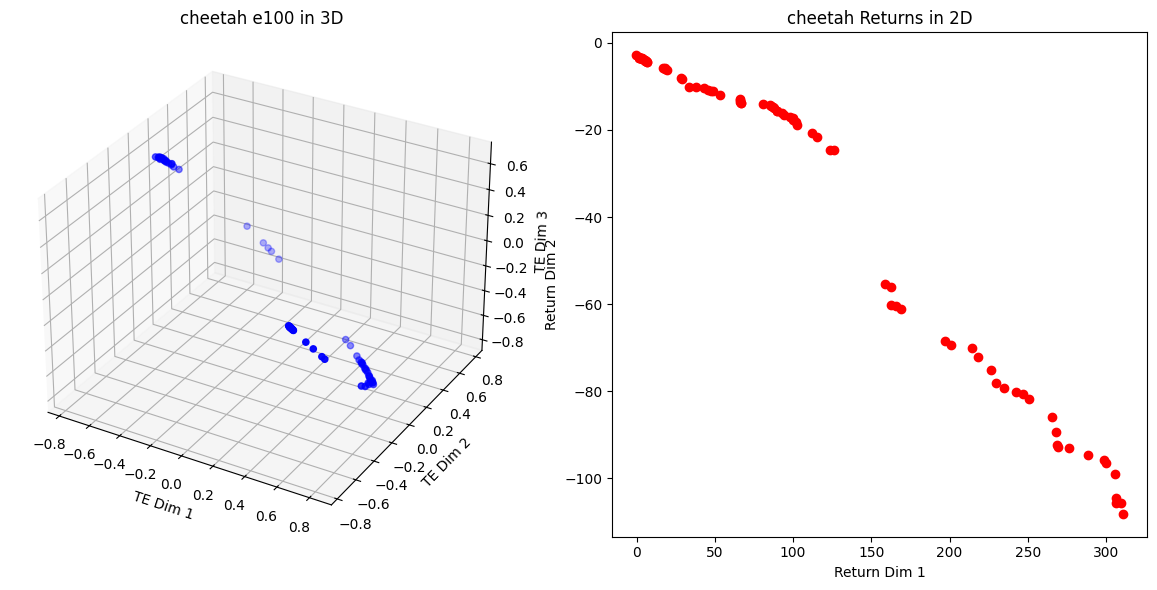

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 6))

# 3D scatter for transformer embeddings
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(all_t_emb_e100[:,0], all_t_emb_e100[:,1], all_t_emb_e100[:,2], c='b', marker='o')
ax1.set_title('cheetah e100 in 3D')
ax1.set_xlabel('TE Dim 1')
ax1.set_ylabel('TE Dim 2')
ax1.set_zlabel('TE Dim 3')

# 2D scatter for returns
ax2 = fig.add_subplot(132)
ax2.scatter(returns[:,0], returns[:,1], c='r', marker='o')
ax2.set_title('cheetah Returns in 2D')
ax2.set_xlabel('Return Dim 1')
ax2.set_ylabel('Return Dim 2')


plt.tight_layout()

plt.show()

## Lipschitz Histograms


Lipschitz constant for policy 0 ([ 310.74908793 -108.12961902], [-0.40991569  0.76672059 -0.47722438]) to 1 ([ 309.29723363 -105.70513637], [-0.73245245  0.10236257  0.56356233]): 0.4515936026958367, d_obj: 2.825950643170885, d_emb: 1.2761812319901569
Lipschitz constant for policy 1 ([ 309.29723363 -105.70513637], [-0.73245245  0.10236257  0.56356233]) to 2 ([ 306.52434554 -105.60651863], [ 0.2647543   0.46668494 -0.7720117 ]): 0.6149043475541199, d_obj: 2.7746412039307944, d_emb: 1.706138939199843
Lipschitz constant for policy 2 ([ 306.52434554 -105.60651863], [ 0.2647543   0.46668494 -0.7720117 ]) to 3 ([ 306.23030094 -104.40296383], [ 0.60166574  0.13850291 -0.7204783 ]): 0.3818926986197352, d_obj: 1.2389537465973897, d_emb: 0.4731473897531087
Lipschitz constant for policy 3 ([ 306.23030094 -104.40296383], [ 0.60166574  0.13850291 -0.7204783 ]) to 4 ([305.56980696 -99.1022567 ], [ 0.61989069 -0.74446297  0.24535036]): 0.24500340715892913, d_obj: 5.3416990176072074, d_emb: 1.30873445

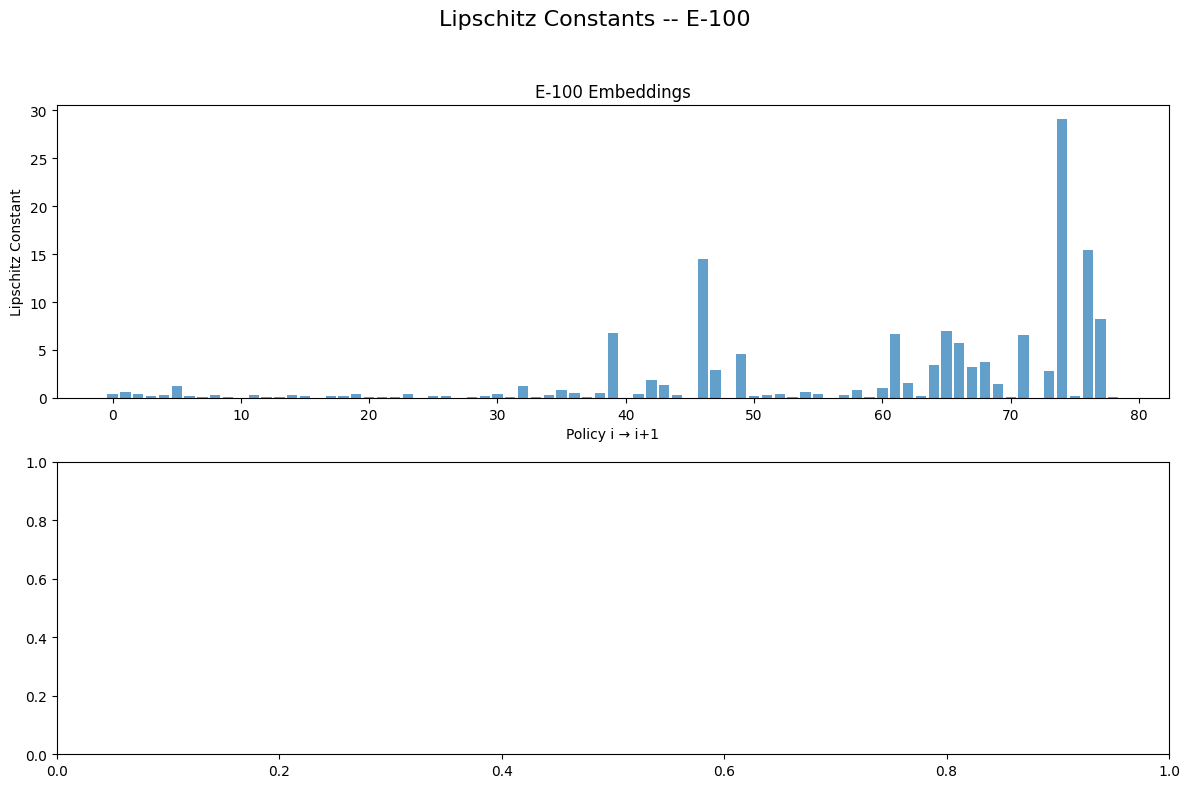

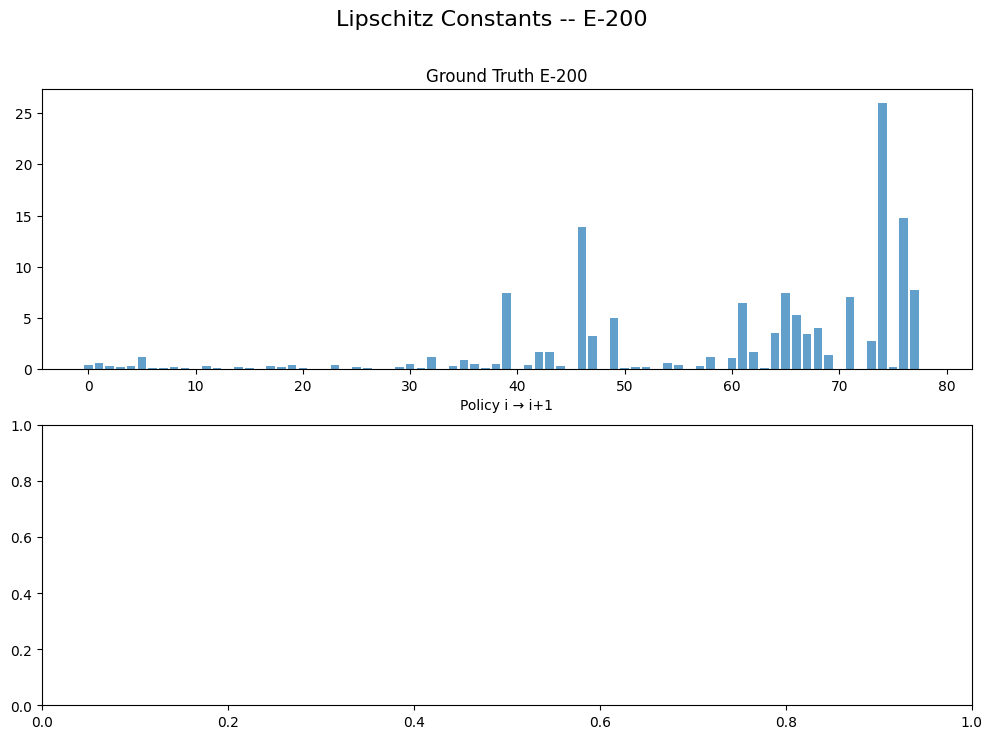

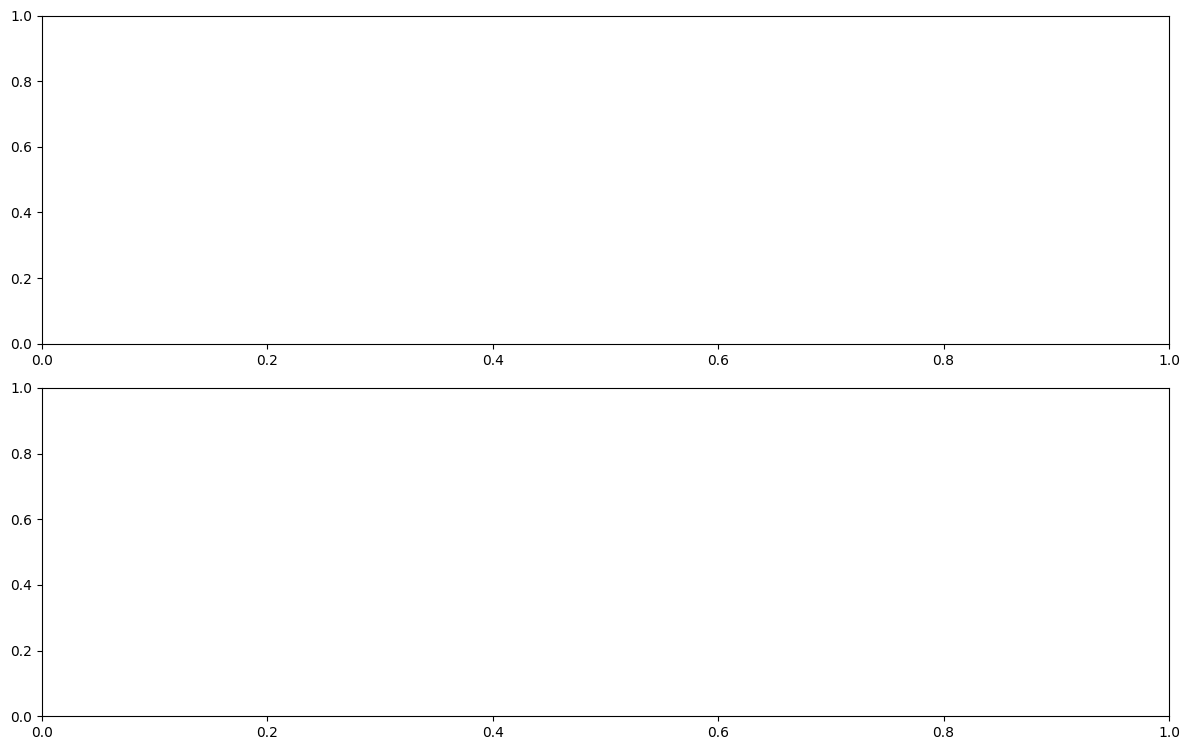

In [18]:
# Makes a histogram of the Lipschitz constants of the GTE embeddings vs the returns

# Compute Lipschitz constants
def compute_lipschitz_constants(pareto_frontier: np.ndarray, embeddings: np.ndarray) -> np.ndarray:
    """
    Compute pairwise Lipschitz constants between consecutive points
    in the Pareto frontier and embedding space.

    Args:
        pareto_frontier: (n_points, d_obj) array of objective values
        embeddings: (n_points, d_emb) array of embeddings

    Returns:
        lipschitz_constants: (n_points-1,) array of Lipschitz constants
    """
    # Lexicographic sort: np.lexsort expects keys in reverse order
    sort_idx = np.lexsort(pareto_frontier.T)
    sorted_pf = pareto_frontier[sort_idx]
    sorted_emb = embeddings[sort_idx]

    lipschitz_constants = []
    for i in range(len(sorted_pf) - 1):
        d_obj = np.linalg.norm(sorted_pf[i+1] - sorted_pf[i])
        d_emb = np.linalg.norm(sorted_emb[i+1] - sorted_emb[i])
        lipschitz_constants.append(d_emb / d_obj)

        print(f"Lipschitz constant for policy {i} ({sorted_pf[i]}, {sorted_emb[i]}) to {i+1} ({sorted_pf[i+1]}, {sorted_emb[i+1]}): {lipschitz_constants[-1]}, d_obj: {d_obj}, d_emb: {d_emb}")

    return np.array(lipschitz_constants)



lipschitz_constants_gt = compute_lipschitz_constants(pareto_frontier=returns, embeddings=all_t_emb_e100)
lipschitz_constants_gt_concave = compute_lipschitz_constants(pareto_frontier=returns, embeddings=all_t_emb_e200)


import matplotlib.pyplot as plt
import numpy as np

# Create 2x1 grid for each figure
fig, axs = plt.subplots(2, figsize=(12, 8))
fig2, axs2 = plt.subplots(2, figsize=(12, 8))
fig3, axs3 = plt.subplots(2, figsize=(12, 8))

# --- Plot 1: Left-Right ---
fig.suptitle("Lipschitz Constants -- E-100", fontsize=16)
axs[0].bar(np.arange(len(lipschitz_constants_gt)), lipschitz_constants_gt, alpha=0.7)
axs[0].set_title("E-100 Embeddings")
axs[0].set_ylabel("Lipschitz Constant")
axs[0].set_xlabel("Policy i → i+1")


fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
fig.savefig("lipschitz_left_right.png", dpi=300, bbox_inches='tight')  # ✅ Save first figure

# --- Plot 2: Concave ---
fig2.suptitle("Lipschitz Constants -- E-200", fontsize=16)
axs2[0].bar(np.arange(len(lipschitz_constants_gt_concave)), lipschitz_constants_gt_concave, alpha=0.7)
axs2[0].set_title("Ground Truth E-200")
axs2[0].set_xlabel("Policy i → i+1")


fig3.tight_layout(rect=[0, 0, 1, 0.95])
fig3.savefig("lipschitz_smooth.png", dpi=300, bbox_inches='tight')  # ✅ Save third figure

plt.show()



